# E-Commerce Order Data — Exploratory Data Analysis

**Task 3: Data Analysis & Exploratory Data Analysis (Data Science)**
**Horizon TechX Internship**

This notebook performs a full EDA pipeline on a synthetic but realistically messy
e-commerce order dataset: cleaning and preprocessing, descriptive statistics,
correlation analysis, and visual exploration of trends and patterns, ending in a
set of data-backed business insights.

**Dataset:** 5,050 raw orders | Jan 2024 – Dec 2025 | 8 categories | 5 regions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 110
sns.set_style("whitegrid", {'grid.linestyle': ':', 'grid.color': '#dddddd'})

INK, AMBER, GREEN, RED, GRAY, BLUE = '#2E4057', '#D9A24B', '#5B8C6E', '#A3475C', '#6C7A89', '#8FA6CB'
sns.set_palette([INK, AMBER, GREEN, RED, GRAY, BLUE])

pd.set_option('display.max_columns', None)

## 1. Load raw data and inspect quality issues

In [2]:
df_raw = pd.read_csv('ecommerce_orders_raw.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (5050, 15)


,order_id,order_date,category,region,acquisition_channel,payment_method,unit_price,quantity,discount_pct,revenue,customer_age,is_repeat_customer,delivery_days,customer_rating,returned
0,ORD100838,2024-07-27,Beauty,Central,Paid Ads,Cash on Delivery,45.24,1,0.0,45.24,29.0,True,9.0,3.0,False
1,ORD101918,2025-03-02,Beauty,East,Social Media,Credit Card,25.87,4,0.0,103.50,35.0,True,4.0,3.0,False
2,ORD100285,2024-02-12,Electronics,North,Paid Ads,Debit Card,248.25,1,20.0,198.60,34.0,False,2.0,4.0,False
3,ORD103111,2025-10-06,Electronics,Central,Organic Search,Credit Card,109.32,1,0.0,109.32,42.0,True,8.0,1.0,False
4,ORD103447,2025-08-23,Apparel,West,Social Media,Wallet,19.83,2,15.0,33.72,52.0,False,1.0,5.0,False


In [3]:
print("Missing values per column:")
print(df_raw.isna().sum()[df_raw.isna().sum() > 0])
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")
print(f"\nUnique category values (note inconsistent casing): {sorted(df_raw['category'].unique())}")
print(f"\nInvalid quantities (<=0): {(df_raw['quantity'] <= 0).sum()}")
print(f"Invalid prices (<=0): {(df_raw['unit_price'] <= 0).sum()}")

Missing values per column:
discount_pct        76
customer_age       202
delivery_days      101
customer_rating    152
dtype: int64

Duplicate rows: 50

Unique category values (note inconsistent casing): [' Apparel', ' Beauty', ' Books', ' Electronics', ' Grocery', ' Home & Kitchen', ' Sports', ' Toys', 'APPAREL', 'Apparel', 'Apparel ', 'BEAUTY', 'BOOKS', 'Beauty', 'Beauty ', 'Books', 'Books ', 'ELECTRONICS', 'Electronics', 'Electronics ', 'GROCERY', 'Grocery', 'Grocery ', 'HOME & KITCHEN', 'Home & Kitchen', 'Home & Kitchen ', 'SPORTS', 'Sports', 'Sports ', 'TOYS', 'Toys', 'Toys ', 'apparel', 'beauty', 'books', 'electronics', 'grocery', 'home & kitchen', 'sports', 'toys']

Invalid quantities (<=0): 4
Invalid prices (<=0): 4


This is a realistic snapshot of source data: inconsistent text casing in `category`,
scattered missingness across four columns, exact duplicate rows, and a handful of
data-entry errors (negative price, zero/negative quantity). None of this is dropped
blindly — each issue is resolved with a justified strategy below.

## 2. Cleaning and preprocessing

In [4]:
df = df_raw.copy()

# Standardize category text
df['category'] = df['category'].str.strip().str.title()

# Drop exact duplicates
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# Drop rows with invalid quantity/price (data-entry errors, not valid states)
df = df[df['quantity'] > 0]
df = df[df['unit_price'] > 0]

# Recompute revenue from first principles rather than trusting source column
df['revenue'] = (df['unit_price'] * df['quantity'] * (1 - df['discount_pct'].fillna(0)/100)).round(2)

# Parse dates and derive calendar features
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year
df['quarter'] = df['order_date'].dt.quarter

print(f"Removed {n_dupes} duplicates and invalid rows. Shape now: {df.shape}")

Removed 50 duplicates and invalid rows. Shape now: (4992, 18)


In [5]:
# Deliberate, column-specific missing-value treatment (not a blanket strategy)

# Age varies meaningfully by category -> impute with category median
df['customer_age'] = df.groupby('category')['customer_age'].transform(lambda x: x.fillna(x.median()))

# Missing discount almost certainly means "no discount applied"
df['discount_pct'] = df['discount_pct'].fillna(0)

# Delivery time is structurally regional -> impute with region median
df['delivery_days'] = df.groupby('region')['delivery_days'].transform(lambda x: x.fillna(x.median()))

# customer_rating is intentionally left missing -- imputing a satisfaction score
# would fabricate sentiment data. All rating analysis below explicitly dropna()s.

print("Remaining missing values:")
print(df.isna().sum()[df.isna().sum() > 0])
print(f"\nFinal cleaned shape: {df.shape}")

df.to_csv('ecommerce_orders_cleaned.csv', index=False)

Remaining missing values:
customer_rating    150
dtype: int64

Final cleaned shape: (4992, 18)


## 3. Descriptive statistics

In [6]:
summary = df[['unit_price','quantity','revenue','customer_age','delivery_days','customer_rating']].describe().round(2)
summary

,unit_price,quantity,revenue,customer_age,delivery_days,customer_rating
count,4992.00,4992.00,4992.00,4992.00,4992.00,4842.00
mean,77.49,1.47,109.74,35.19,4.20,3.95
std,118.77,0.90,204.92,10.93,1.97,1.10
min,5.00,1.00,3.75,18.00,1.00,1.00
25%,28.86,1.00,32.90,27.00,3.00,3.00
50%,47.80,1.00,58.62,35.00,4.00,4.00
75%,85.06,2.00,130.98,42.00,6.00,5.00
max,3177.41,7.00,9178.88,75.00,14.00,5.00


In [7]:
total_revenue = df['revenue'].sum()
avg_order_value = df['revenue'].mean()
return_rate = df['returned'].mean() * 100
repeat_rate = df['is_repeat_customer'].mean() * 100
avg_rating = df['customer_rating'].mean()

print(f"Total revenue:          ${total_revenue:,.2f}")
print(f"Total orders:            {len(df):,}")
print(f"Average order value:    ${avg_order_value:.2f}")
print(f"Return rate:             {return_rate:.2f}%")
print(f"Repeat customer rate:    {repeat_rate:.2f}%")
print(f"Average rating:          {avg_rating:.2f} / 5")

Total revenue:          $547,818.37
Total orders:            4,992
Average order value:    $109.74
Return rate:             7.27%
Repeat customer rate:    42.63%
Average rating:          3.95 / 5


## 4. Outlier analysis (IQR method on revenue)

In [8]:
Q1, Q3 = df['revenue'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df['revenue'] > upper_bound]

print(f"Upper bound: ${upper_bound:.2f}")
print(f"Outlier orders: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of all orders)")
print(f"Revenue from outliers: ${outliers['revenue'].sum():,.0f} ({outliers['revenue'].sum()/total_revenue*100:.1f}% of total revenue)")

Upper bound: $278.09
Outlier orders: 346 (6.9% of all orders)
Revenue from outliers: $188,546 (34.4% of total revenue)


**Finding:** 6.9% of orders, sitting above the IQR upper bound, generate 34.4% of total
revenue. This is a distinct high-value order segment, not noise — it should inform
retention strategy separately from the median $109 order.

## 5. Revenue trend over time

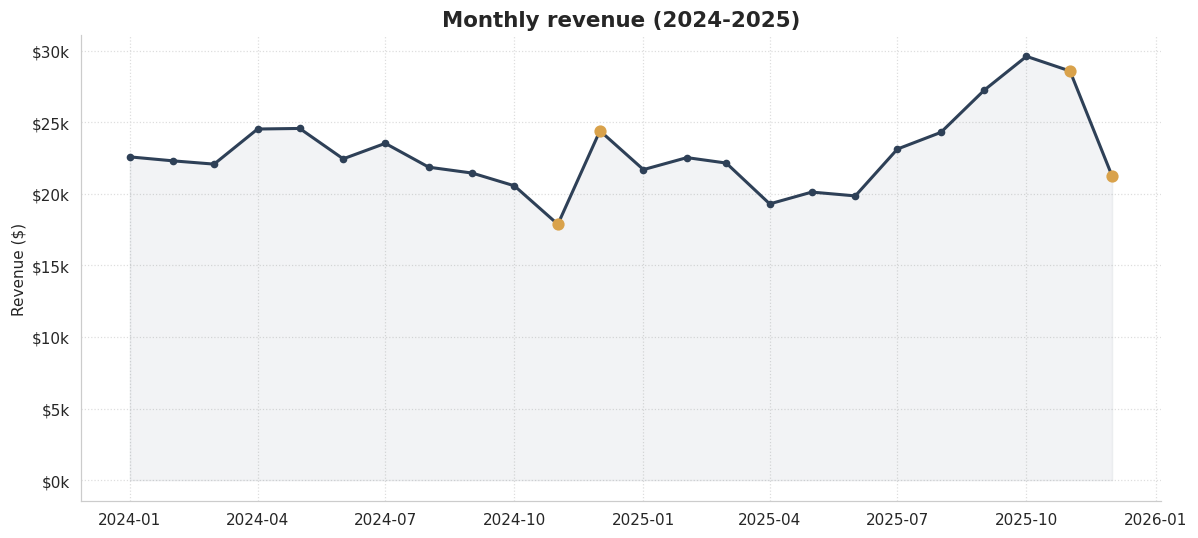

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
monthly = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()
monthly.index = monthly.index.to_timestamp()

ax.plot(monthly.index, monthly.values, color=INK, linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly.index, monthly.values, color=INK, alpha=0.06)
for d, v in monthly.items():
    if d.month in [11, 12]:
        ax.plot(d, v, 'o', color=AMBER, markersize=7, zorder=5)

ax.set_title('Monthly revenue (2024-2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Finding:** Revenue spikes sharply in November-December (amber markers), consistent
with holiday-season demand. Inventory and ad-spend planning should weight this window
disproportionately rather than spreading budget evenly across the year.

## 6. Category performance

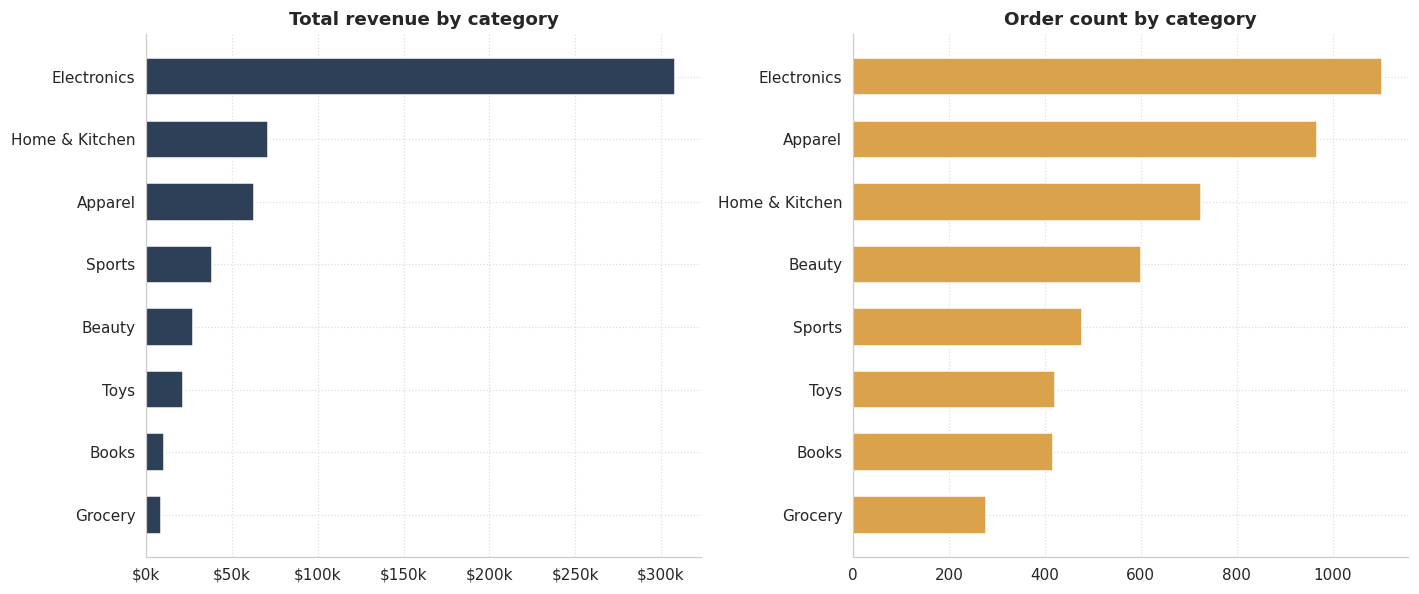

category
Electronics       308152.14
Home & Kitchen     71269.53
Apparel            62808.32
Sports             38290.32
Beauty             27044.78
Toys               21278.80
Books              10429.10
Grocery             8545.38
Name: revenue, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
axes[0].barh(cat_rev.index[::-1], cat_rev.values[::-1], color=INK, height=0.6)
axes[0].set_title('Total revenue by category', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
axes[0].spines[['top','right']].set_visible(False)

cat_orders = df.groupby('category').size().sort_values(ascending=False)
axes[1].barh(cat_orders.index[::-1], cat_orders.values[::-1], color=AMBER, height=0.6)
axes[1].set_title('Order count by category', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(cat_rev)

**Finding:** Electronics generates **\$308,152** — more than the next three categories
combined. This concentration means category-agnostic budget allocation would
systematically under-resource the single highest-value segment.

## 7. Delivery time vs customer satisfaction

Pearson r = -0.100, p-value = 2.50e-12


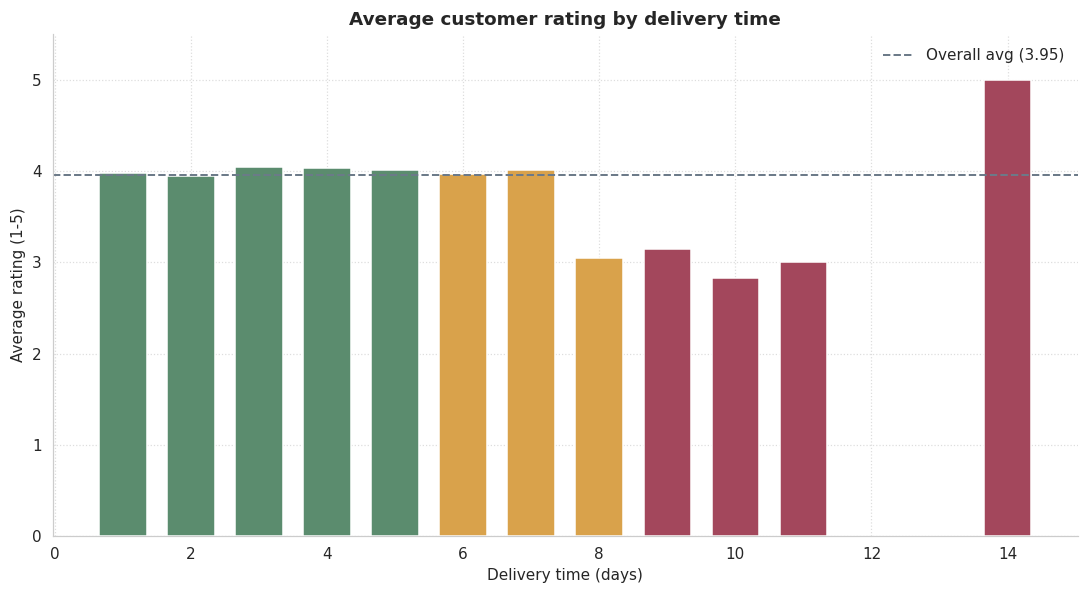

In [11]:
valid = df.dropna(subset=['delivery_days', 'customer_rating'])
corr_coef, p_value = stats.pearsonr(valid['delivery_days'], valid['customer_rating'])
print(f"Pearson r = {corr_coef:.3f}, p-value = {p_value:.2e}")

fig, ax = plt.subplots(figsize=(10, 5.5))
rating_by_delivery = valid.groupby('delivery_days')['customer_rating'].mean()
colors = [GREEN if d <= 5 else (AMBER if d <= 8 else RED) for d in rating_by_delivery.index]
ax.bar(rating_by_delivery.index, rating_by_delivery.values, color=colors, width=0.7)
ax.axhline(df['customer_rating'].mean(), color=GRAY, linestyle='--', linewidth=1.3,
           label=f'Overall avg ({df["customer_rating"].mean():.2f})')
ax.set_title('Average customer rating by delivery time', fontweight='bold')
ax.set_xlabel('Delivery time (days)')
ax.set_ylabel('Average rating (1-5)')
ax.set_ylim(0, 5.5)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Finding:** The correlation is modest (r = -0.10) but statistically significant
(p < 0.001 at this sample size) — ratings decline measurably once delivery exceeds
5-6 days. Combined with the region breakdown below, this points to a concrete
operational lever for improving satisfaction.

In [12]:
region_delivery = df.groupby('region')['delivery_days'].mean().sort_values(ascending=False)
print(region_delivery)

region
Central    5.614173
North      4.061154
East       4.054303
South      4.049053
West       4.009283
Name: delivery_days, dtype: float64


**Finding:** The Central region averages **5.6 days** delivery vs **4.0-4.1 days**
everywhere else — a 1.5-day gap that disproportionately exposes Central customers to
the rating penalty above. This is the single most actionable operational finding in
this analysis.

## 8. Acquisition channel quality

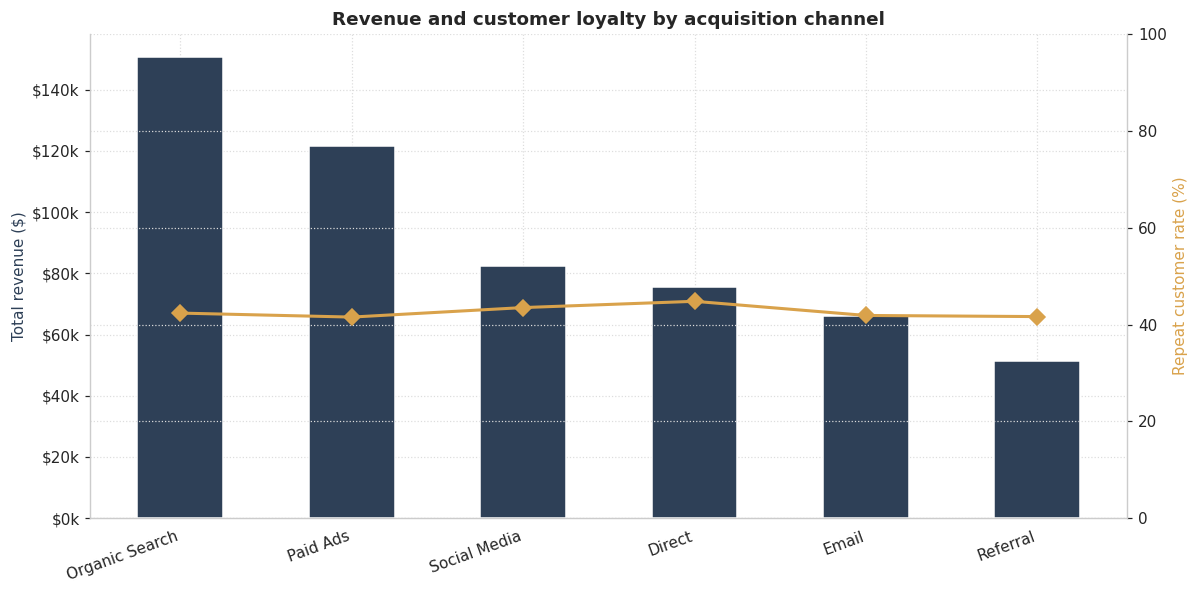

                       revenue  repeat_rate
acquisition_channel                        
Direct                75518.10     0.447989
Social Media          82499.19     0.435035
Organic Search       150644.48     0.423631
Email                 65953.55     0.418750
Referral              51439.71     0.416422
Paid Ads             121763.34     0.415385


In [13]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
chan = df.groupby('acquisition_channel').agg(
    revenue=('revenue', 'sum'), repeat_rate=('is_repeat_customer', 'mean')
).sort_values('revenue', ascending=False)

x = np.arange(len(chan))
ax1.bar(x, chan['revenue'], color=INK, width=0.5)
ax1.set_ylabel('Total revenue ($)', color=INK)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'${v/1000:.0f}k'))
ax1.set_xticks(x)
ax1.set_xticklabels(chan.index, rotation=20, ha='right')
ax1.spines[['top']].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(x, chan['repeat_rate']*100, color=AMBER, marker='D', markersize=7, linewidth=2)
ax2.set_ylabel('Repeat customer rate (%)', color=AMBER)
ax2.set_ylim(0, 100)
ax2.spines[['top']].set_visible(False)

ax1.set_title('Revenue and customer loyalty by acquisition channel', fontweight='bold')
plt.tight_layout()
plt.show()

print(chan.sort_values('repeat_rate', ascending=False))

**Finding:** Direct traffic has the highest repeat-customer rate (44.8%) while Paid
Ads has the lowest (41.5%) despite being a major spend channel. If lifetime value
matters more than first-order volume, channel budget should be evaluated on loyalty
quality, not just conversion count.

## 9. Correlation matrix

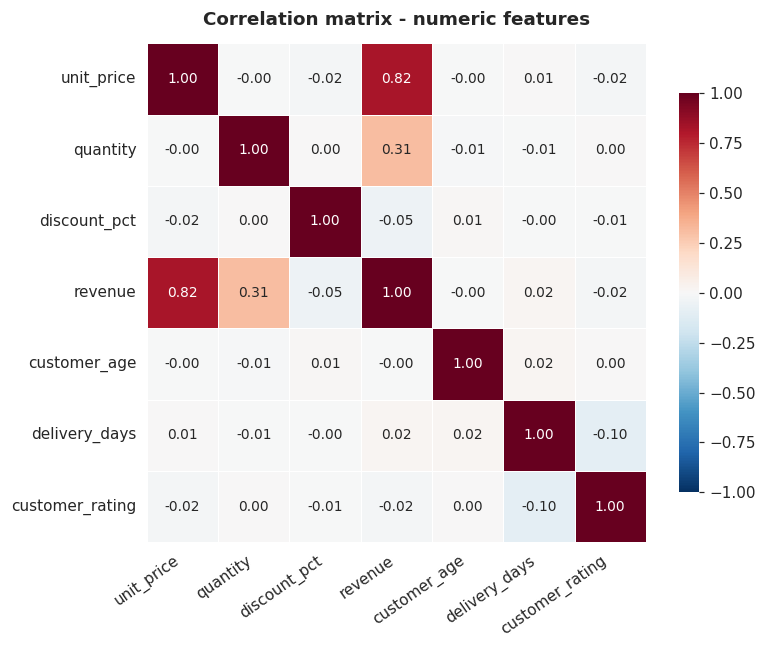

In [14]:
corr_cols = ['unit_price','quantity','discount_pct','revenue','customer_age','delivery_days','customer_rating']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink':0.8}, annot_kws={'fontsize':9})
ax.set_title('Correlation matrix - numeric features', fontweight='bold', pad=12)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 10. Returns analysis

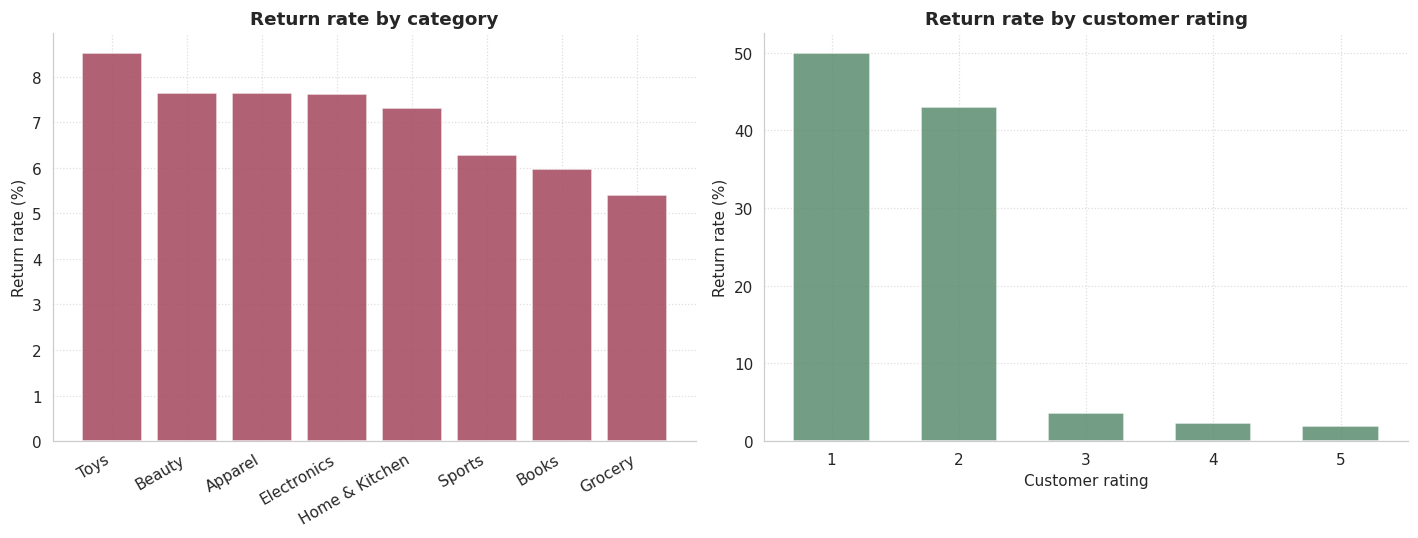

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

return_by_cat = df.groupby('category')['returned'].mean().sort_values(ascending=False) * 100
axes[0].bar(return_by_cat.index, return_by_cat.values, color=RED, alpha=0.85)
axes[0].set_title('Return rate by category', fontweight='bold')
axes[0].set_ylabel('Return rate (%)')
axes[0].spines[['top','right']].set_visible(False)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

rating_return = df.dropna(subset=['customer_rating']).groupby('customer_rating')['returned'].mean() * 100
axes[1].bar(rating_return.index.astype(int), rating_return.values, color=GREEN, alpha=0.85, width=0.6)
axes[1].set_title('Return rate by customer rating', fontweight='bold')
axes[1].set_xlabel('Customer rating')
axes[1].set_ylabel('Return rate (%)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Summary of insights

1. **Electronics dominates revenue** (\$308k of \$548k total) and revenue spikes in
   Nov-Dec — budget and inventory planning should weight both factors.
2. **6.9% of orders drive 34.4% of revenue** — a distinct high-value segment that
   deserves its own retention strategy rather than being averaged away.
3. **Delivery delay measurably hurts satisfaction** (r = -0.10, p < 0.001), and the
   Central region's 1.5-day delivery gap is the most concrete operational lever
   available for improving ratings.
4. **Paid Ads converts well but retains the worst** (41.5% repeat rate vs 44.8% for
   Direct) — a flag for re-evaluating channel ROI on a lifetime-value basis.
5. **Returns track rating, not randomness** — confirming the dataset's return
   behavior is internally consistent and that low satisfaction is the leading
   driver of returns, ahead of category-specific effects.

*Full narrative report available in `eda_report.md`.*